# 5. Model

Training Naive Bayes and Logistic Regression on the split from the previous notebook, comparing them on the test set, and saving the best one.

From the feature engineering notebook: CountVectorizer, no stopword removal, and `class_weight='balanced'` for Logistic Regression.

In [1]:
import re
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, ConfusionMatrixDisplay)

In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

X_train, y_train = train['clean_message'], train['label_num']
X_test, y_test = test['clean_message'], test['label_num']

print(X_train.shape, X_test.shape)

(4100,) (1026,)


## Training

Each model is a Pipeline with the vectorizer and the classifier together. The pipeline fits the vectorizer on the training messages only, and reuses that same vocabulary when predicting on new text.

In [3]:
nb_model = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB())
])

lr_model = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

nb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


## Evaluation

Spam is the positive class (1), so precision, recall and F1 below are all for spam. Precision tells how many of the messages marked as spam really are spam, and recall tells how many of the real spam messages were caught.

In [4]:
models = {
    'Naive Bayes': nb_model,
    'Logistic Regression': lr_model,
}

predictions = {}
rows = []
for name, model in models.items():
    pred = model.predict(X_test)
    predictions[name] = pred
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-score': f1_score(y_test, pred),
    })

results = pd.DataFrame(rows).set_index('Model').round(4)
results

,Accuracy,Precision,Recall,F1-score
Model,,,,
Naive Bayes,0.9815,0.9573,0.8889,0.9218
Logistic Regression,0.9737,0.9304,0.8492,0.8880


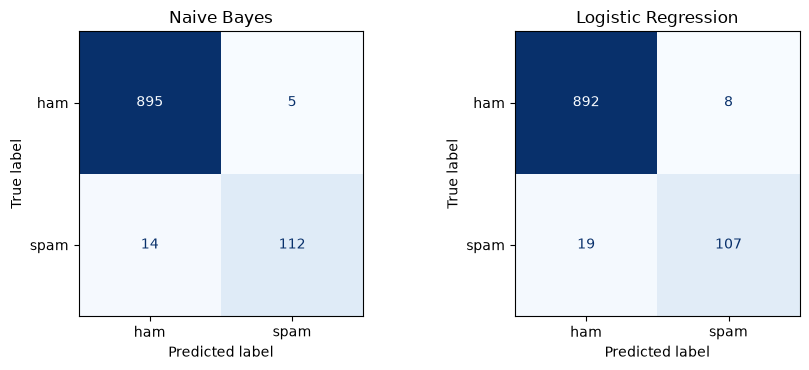

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))

for ax, name in zip(axes, models):
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions[name], display_labels=['ham', 'spam'],
        cmap='Blues', colorbar=False, ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [6]:
for name in models:
    print(name)
    print(classification_report(y_test, predictions[name], target_names=['ham', 'spam']))

Naive Bayes
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       900
        spam       0.96      0.89      0.92       126

    accuracy                           0.98      1026
   macro avg       0.97      0.94      0.96      1026
weighted avg       0.98      0.98      0.98      1026

Logistic Regression
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       900
        spam       0.93      0.85      0.89       126

    accuracy                           0.97      1026
   macro avg       0.95      0.92      0.94      1026
weighted avg       0.97      0.97      0.97      1026



Naive Bayes is better than Logistic Regression on all four numbers: precision 0.957 vs 0.930, recall 0.889 vs 0.849, F1 0.922 vs 0.888. Looking at the confusion matrices, Naive Bayes missed 14 spam messages and had 5 false alarms, and Logistic Regression missed 19 and had 8.

Accuracy is 98.2% and 97.4%, but that number alone doesn't say much here, since always guessing "ham" would already be right about 88% of the time. The test set has only 126 spam messages, so the gap is a handful of messages. In the cross-validation the two models were closer (0.935 vs 0.932), so I wouldn't say Naive Bayes is much better, only that it is at least as good.

## Final model

The final model is picked from the table by the best F1-score. F1 is used because both mistakes matter: missing a spam message and marking a normal message as spam.

In [7]:
best_name = results['F1-score'].idxmax()
final_model = models[best_name]
print('Final model:', best_name)

Final model: Naive Bayes


It is already trained on the training set only, so the test results above are the results of this exact pipeline. Let me look at the mistakes it makes on the test set.

In [8]:
test_pred = final_model.predict(X_test)

missed_spam = test[(y_test == 1) & (test_pred == 0)]
false_alarms = test[(y_test == 0) & (test_pred == 1)]

print('Spam that was missed:', len(missed_spam))
for msg in missed_spam['clean_message'].head(5):
    print('-', msg)

print()
print('Ham that was marked as spam:', len(false_alarms))
for msg in false_alarms['clean_message'].head(5):
    print('-', msg)

Spam that was missed: 14
- babe u want me dont u baby im nasty and have a thing 4 filthyguys fancy a rude time with a sexy bitch how about we go slo n hard txt xxx slo 4msgs
- call 09090900040 listen to extreme dirty live chat going on in the office right now total privacy no one knows your sic listening 60p min 24 7mp 0870753331018
- rct thnq adrian for u text rgds vatian
- tbs persolvo been chasing us since sept for 38 definitely not paying now thanks to your information we will ignore them kath manchester
- block breaker now comes in deluxe format with new features and great graphics from t mobile buy for just 5 by replying get bbdeluxe and take the challenge

Ham that was marked as spam: 5
- waiting for your call
- i liked the new mobile
- hi mobile no lt gt has added you in their contact list on www fullonsms com it s a great place to send free sms to people for more visit fullonsms com
- have you laid your airtel line to rest
- hey great deal farm tour 9am to 5pm 95 pax 50 deposi

Some of the missed spam doesn't use the usual words like "free" or "prize" (adult chat lines, odd messages like the "persolvo" one). A bag-of-words model only sees which words are present, so these are hard for it. The false alarms are normal messages that sound a bit like promotions, for example the one about a free SMS website.

## Saving the pipeline

In [9]:
joblib.dump(final_model, 'models/spam_pipeline.joblib')

['models/spam_pipeline.joblib']

In [10]:
# load it back and make sure it gives the same predictions
loaded_model = joblib.load('models/spam_pipeline.joblib')
print((loaded_model.predict(X_test) == test_pred).all())

True


## Predicting new messages

The pipeline was trained on cleaned text, so new messages have to go through the same cleaning as in `preprocessing.ipynb` first.

In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [12]:
new_messages = [
    "Congratulations! You won a free prize. Click now!",
    "Hey, are we still meeting at 5?",
    "URGENT! Your mobile number has won a £2000 cash prize. Call 09061234567 to claim now",
    "Can you send me the notes from yesterday's class?",
    "Free entry! Text WIN to 80082 to get a free ringtone",
    "Ok, I'll call you when I reach home",
]

for msg in new_messages:
    cleaned = clean_text(msg)
    pred = loaded_model.predict([cleaned])[0]
    spam_prob = loaded_model.predict_proba([cleaned])[0][1]

    label = 'spam' if pred == 1 else 'ham'
    print(f'{label.upper():4}  (spam probability {spam_prob:.2f})  {msg}')

SPAM  (spam probability 1.00)  Congratulations! You won a free prize. Click now!
HAM   (spam probability 0.00)  Hey, are we still meeting at 5?
SPAM  (spam probability 1.00)  URGENT! Your mobile number has won a £2000 cash prize. Call 09061234567 to claim now
HAM   (spam probability 0.00)  Can you send me the notes from yesterday's class?
SPAM  (spam probability 1.00)  Free entry! Text WIN to 80082 to get a free ringtone
HAM   (spam probability 0.00)  Ok, I'll call you when I reach home


## Using the saved model later

In another notebook or script the model can be loaded and used like this:

```python
import joblib

model = joblib.load('models/spam_pipeline.joblib')
prediction = model.predict([clean_text('Your message here')])[0]   # 1 = spam, 0 = ham
```

`clean_text` is the same function as above. The model should be loaded with the same scikit-learn version it was saved with (1.8.0 here, see `requirements.txt`).

## Summary

- Naive Bayes was picked for the best F1-score on the test set (0.922, precision 0.957, recall 0.889). The cross-validation in the feature engineering notebook also had it slightly ahead of Logistic Regression.
- The final pipeline (CountVectorizer + Naive Bayes) is saved in `models/spam_pipeline.joblib`.
- All six example messages were classified as expected.